In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings('ignore')

In [29]:
df = pd.read_csv('resume_dataset_200k_enhanced.csv')
df.head()

,candidate_id,age,education_level,university_tier,cgpa,internships,projects,programming_languages,certifications,experience_years,hackathons,research_papers,skills_score,hired,soft_skills_score,resume_length_words,company_type
0,1,27,Bachelors,Tier 2,8.16,2,7,2,2,0.33,0,0,21.0,1,5.62,409,MNC
1,2,24,Bachelors,Tier 3,6.35,3,2,2,2,4.99,0,0,11.0,1,9.66,237,Startup
2,3,33,Bachelors,Tier 3,7.78,0,2,4,2,0.93,0,0,15.0,1,8.12,435,Startup
3,4,31,Masters,Tier 3,6.92,2,1,4,1,0.37,0,0,11.5,1,7.19,340,MNC
4,5,28,Masters,Tier 2,8.24,3,0,1,2,0.33,0,0,5.0,0,4.09,371,Mid-size


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   candidate_id           200000 non-null  int64  
 1   age                    200000 non-null  int64  
 2   education_level        200000 non-null  object 
 3   university_tier        200000 non-null  object 
 4   cgpa                   200000 non-null  float64
 5   internships            200000 non-null  int64  
 6   projects               200000 non-null  int64  
 7   programming_languages  200000 non-null  int64  
 8   certifications         200000 non-null  int64  
 9   experience_years       200000 non-null  float64
 10  hackathons             200000 non-null  int64  
 11  research_papers        200000 non-null  int64  
 12  skills_score           200000 non-null  float64
 13  hired                  200000 non-null  int64  
 14  soft_skills_score      200000 non-nu

In [31]:
categorial_columns = ['education_level', 'university_tier', 'company_type']
numeric_columns = [i for i in df.columns if i not in categorial_columns]
numeric_columns

['candidate_id',
 'age',
 'cgpa',
 'internships',
 'projects',
 'programming_languages',
 'certifications',
 'experience_years',
 'hackathons',
 'research_papers',
 'skills_score',
 'hired',
 'soft_skills_score',
 'resume_length_words']

<Axes: >

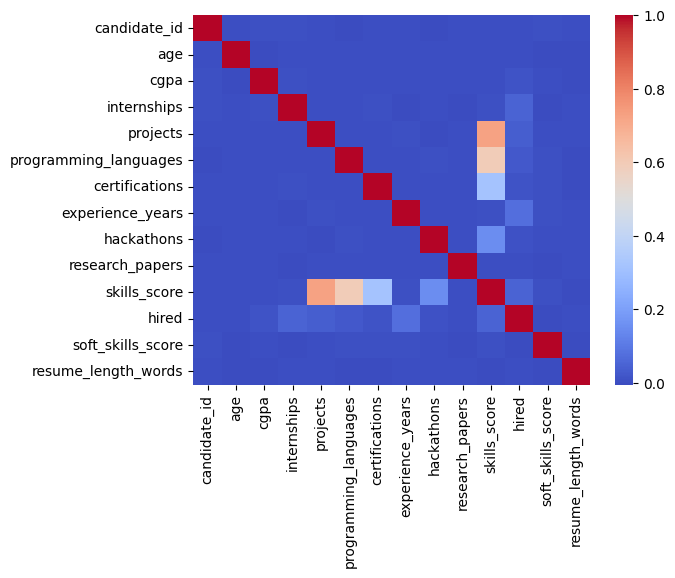

In [32]:
corr_mat = df.corr(numeric_only=True)
sns.heatmap(corr_mat, annot=False, cmap='coolwarm', fmt=".2f")

In [33]:
df.head()

,candidate_id,age,education_level,university_tier,cgpa,internships,projects,programming_languages,certifications,experience_years,hackathons,research_papers,skills_score,hired,soft_skills_score,resume_length_words,company_type
0,1,27,Bachelors,Tier 2,8.16,2,7,2,2,0.33,0,0,21.0,1,5.62,409,MNC
1,2,24,Bachelors,Tier 3,6.35,3,2,2,2,4.99,0,0,11.0,1,9.66,237,Startup
2,3,33,Bachelors,Tier 3,7.78,0,2,4,2,0.93,0,0,15.0,1,8.12,435,Startup
3,4,31,Masters,Tier 3,6.92,2,1,4,1,0.37,0,0,11.5,1,7.19,340,MNC
4,5,28,Masters,Tier 2,8.24,3,0,1,2,0.33,0,0,5.0,0,4.09,371,Mid-size


In [34]:
def univertier_numeric(tier):
    if tier == 'Tier 2':
        return 2
    if tier == 'Tier 1':
        return 1
    return 3

In [35]:
df.university_tier = df.university_tier.apply(univertier_numeric)

In [36]:
df = pd.get_dummies(df)

In [37]:
X = df.drop(['candidate_id', 'hired'], axis = 1)
y = df.hired

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=5, test_size=0.3)

In [39]:
lr = LogisticRegression(tol = 1e-10)

In [40]:
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,1e-10
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [41]:
y_pred = lr.predict(X_test)

In [42]:
accuracy_score(y_pred, y_test)

0.70665

In [43]:
lr_grid = LogisticRegression()

In [44]:
parameters = {
    'tol': [1e-3, 1e-5, 1e-7],
    'penalty': ['l1', 'l2', 'elasticnet', None],
    'max_iter': range(100, 500, 100),
    'C': [0.6, 0.8, 1., 1.3],
    'l1_ratio': [0., 0.1, 0.2]
}

In [45]:
clf = GridSearchCV(lr_grid, parameters, cv = 3, n_jobs=5, verbose=2)

In [46]:
clf.fit(X_train, y_train)

Fitting 3 folds for each of 576 candidates, totalling 1728 fits


,estimator,LogisticRegression()
,param_grid,"{'C': [0.6, 0.8, ...], 'l1_ratio': [0.0, 0.1, ...], 'max_iter': range(100, 500, 100), 'penalty': ['l1', 'l2', ...], ...}"
,scoring,None
,n_jobs,5
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [47]:
clf.best_params_

{'C': 0.6, 'l1_ratio': 0.0, 'max_iter': 100, 'penalty': 'l2', 'tol': 0.001}

In [48]:
best_log = clf.best_estimator_

In [49]:
y_pred_best = best_log.predict(X_test)

In [50]:
accuracy_score(y_pred_best, y_test)

0.70665

In [51]:
dt = DecisionTreeClassifier()

In [52]:
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [53]:
y_pred_dt = dt.predict(X_test)

In [54]:
accuracy_score(y_pred_dt, y_test)

0.5827

In [55]:
dt_grid = DecisionTreeClassifier()

In [56]:
param_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': range(3, 25, 3),
    'min_samples_split': range(2, 11, 2),
    'min_samples_leaf': range(2, 11, 2),
    'max_features': ['sqrt', 'log2'],
}

In [57]:
clf_dt = GridSearchCV(dt_grid, param_dt, cv = 3, n_jobs=7, verbose=2)

In [58]:
clf_dt.fit(X_train, y_train)

Fitting 3 folds for each of 800 candidates, totalling 2400 fits


,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': range(3, 25, 3), 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': range(2, 11, 2), ...}"
,scoring,None
,n_jobs,7
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [59]:
clf_dt.best_params_

{'criterion': 'gini',
 'max_depth': 3,
 'max_features': 'log2',
 'min_samples_leaf': 6,
 'min_samples_split': 10}

In [60]:
best_dt = clf_dt.best_estimator_

In [61]:
y_pred_best_dt = best_dt.predict(X_test)

In [62]:
accuracy_score(y_pred_best_dt, y_test)

0.70665